In [1]:
import sys
sys.path.append('../')
import src.data_loader
import importlib
importlib.reload(src.data_loader)
from src.data_loader import load_data
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
df, features = load_data("../data/raw/data.xls")
print(features)

X1                      LIMIT_BAL
X2                            SEX
X3                      EDUCATION
X4                       MARRIAGE
X5                            AGE
X6                          PAY_0
X7                          PAY_2
X8                          PAY_3
X9                          PAY_4
X10                         PAY_5
X11                         PAY_6
X12                     BILL_AMT1
X13                     BILL_AMT2
X14                     BILL_AMT3
X15                     BILL_AMT4
X16                     BILL_AMT5
X17                     BILL_AMT6
X18                      PAY_AMT1
X19                      PAY_AMT2
X20                      PAY_AMT3
X21                      PAY_AMT4
X22                      PAY_AMT5
X23                      PAY_AMT6
Y      default payment next month
Name: 0, dtype: object


In [ ]:
print(df.shape)
print(df.iloc[[0]]) #features
df.describe()

(30000, 24)
      X1 X2 X3 X4  X5 X6 X7  X8  X9 X10  ... X15 X16 X17 X18  X19 X20 X21 X22  \
1  20000  2  2  1  24  2  2  -1  -1  -2  ...   0   0   0   0  689   0   0   0   

  X23  Y  
1   0  1  

[1 rows x 24 columns]


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,...,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,81,2,7,4,56,11,11,11,11,10,...,21548,21010,20604,7943,7899,7518,6937,6897,6939,2
top,50000,2,2,2,29,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
freq,3365,18112,14030,15964,1605,14737,15730,15764,16455,16947,...,3195,3506,4020,5249,5396,5968,6408,6703,7173,23364


In [ ]:
df.isnull().any().any()

np.False_

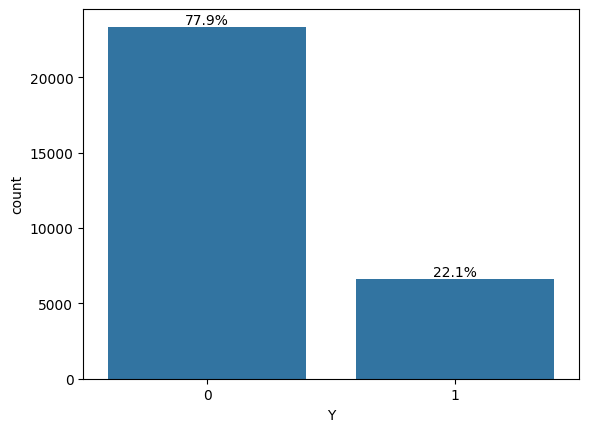

In [ ]:
ax = sns.countplot(x="Y", data=df)

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.savefig("../imgs/class_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

Y      1.000000
X6     0.324794
X7     0.263551
X8     0.235253
X9     0.216614
X10    0.204149
X11    0.186866
X1     0.153520
X18    0.072929
X19    0.058579
X21    0.056827
X20    0.056250
X22    0.055124
X23    0.053183
X2     0.039961
X3     0.028006
X4     0.024339
X12    0.019644
X13    0.014193
X14    0.014076
X5     0.013890
X15    0.010156
X16    0.006760
X17    0.005372
Name: Y, dtype: float64


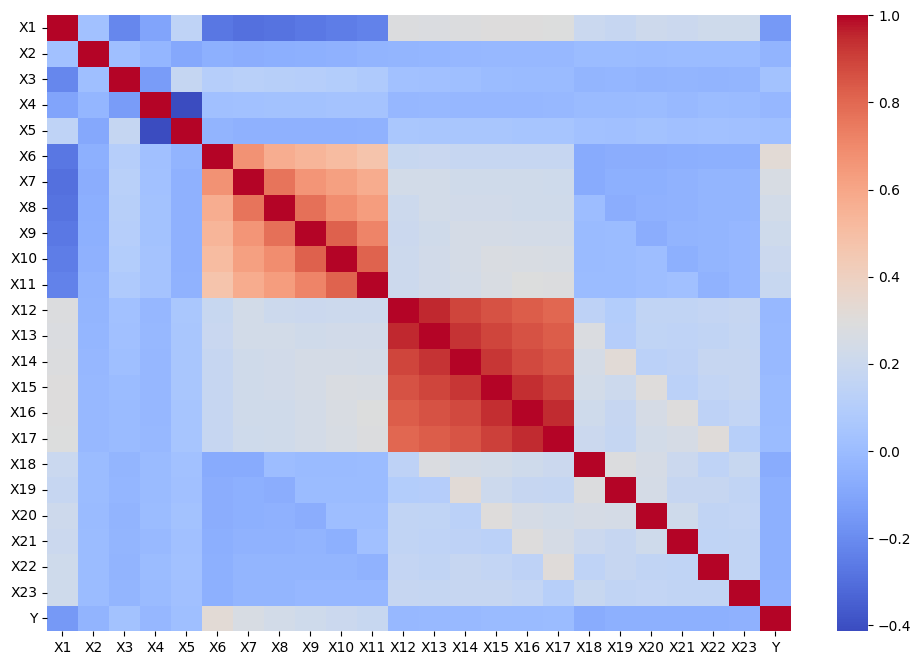

In [ ]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
# Quantify what the heatmap shows
corr_with_y = df.corr()['Y'].abs().sort_values(ascending=False)
print(corr_with_y)
plt.savefig("../imgs/correlation_heatmap.png")
r = corr_with_y[1:].round(4).to_frame()
r = r.map(lambda x: f"{x:.4f}")
fig, ax = plt.subplots()
ax.axis('off')  # hide axes

table = ax.table(cellText=r.values,
                 colLabels=r.columns,
                 rowLabels=r.index,
                 loc='center')

plt.savefig("../imgs/correlation_table.png", bbox_inches='tight', dpi=300)
plt.close()
#X6 to X11 are correlated with each other, out of them X6 is the most correlated with Y. overall are most correlated with Y, but the correlation is not strong.
#X12 to X17 are correlated with each other, but nonne are correlated with Y.
#X1 is also correlated with Y, but the correlation is not strong.
#X18 is the most correlated out of X18 to X23 group, but the correlation is not strong.

In [ ]:
corr_with_x1 = df.corr()['X1'].abs().sort_values(ascending=False)
print(corr_with_x1) #x1 seems to have good correlation with most of the features. 

X1     1.000000
X7     0.296382
X16    0.295562
X15    0.293988
X17    0.290389
X8     0.286123
X12    0.285430
X14    0.283236
X13    0.278314
X6     0.271214
X9     0.267460
X10    0.249411
X11    0.235195
X23    0.219595
X3     0.219161
X22    0.217202
X20    0.210167
X21    0.203242
X18    0.195236
X19    0.178408
Y      0.153520
X5     0.144713
X4     0.108139
X2     0.024755
Name: X1, dtype: float64


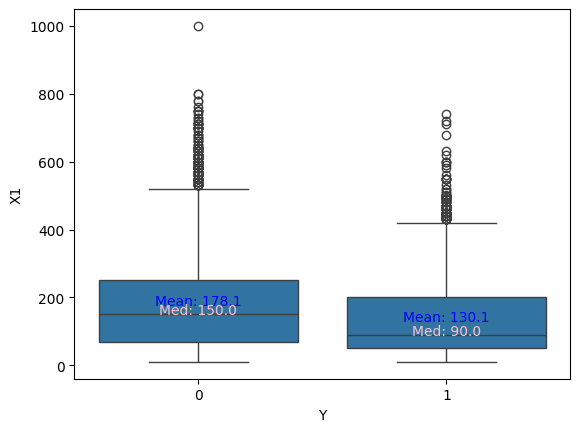

In [ ]:
y = df["X1"] / 1000
ax = sns.boxplot(x="Y", y=y, data=df)

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

# compute stats
stats = df.groupby('Y')['X1'].agg(['median', 'mean']) / 1000

# annotate
for i, category in enumerate(stats.index):
    mean = stats.loc[category, 'mean']
    median = stats.loc[category, 'median']
    ax.text(i, mean, f'Mean: {mean:.1f}', ha='center', color='blue')
    ax.text(i, median, f'Med: {median:.1f}', ha='center', color='pink')

plt.savefig("../imgs/x1_boxplot.png", bbox_inches="tight", dpi=300)
plt.show()

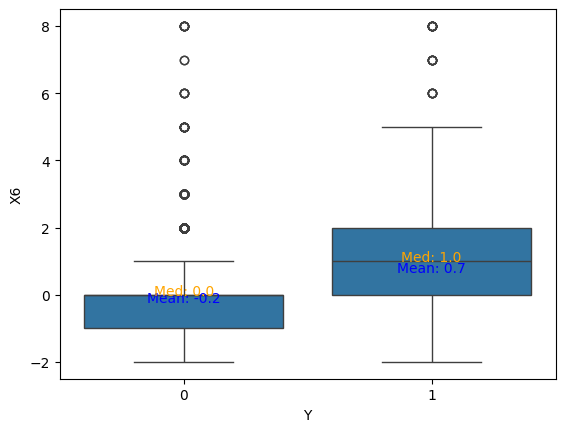

In [ ]:
y = df["X6"]
ax = sns.boxplot(x="Y", y=y, data=df)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
stats = df.groupby('Y')['X6'].agg(['median', 'mean', lambda x: x.quantile(0.75)])

for i, category in enumerate(stats.index):
    mean = stats.loc[category, 'mean']
    median = stats.loc[category, 'median']
    ax.text(i, mean, f'Mean: {mean:.1f}', ha='center', color='blue')
    ax.text(i, median, f'Med: {median:.1f}', ha='center', color='orange')
plt.savefig("../imgs/x6_boxplot.png")

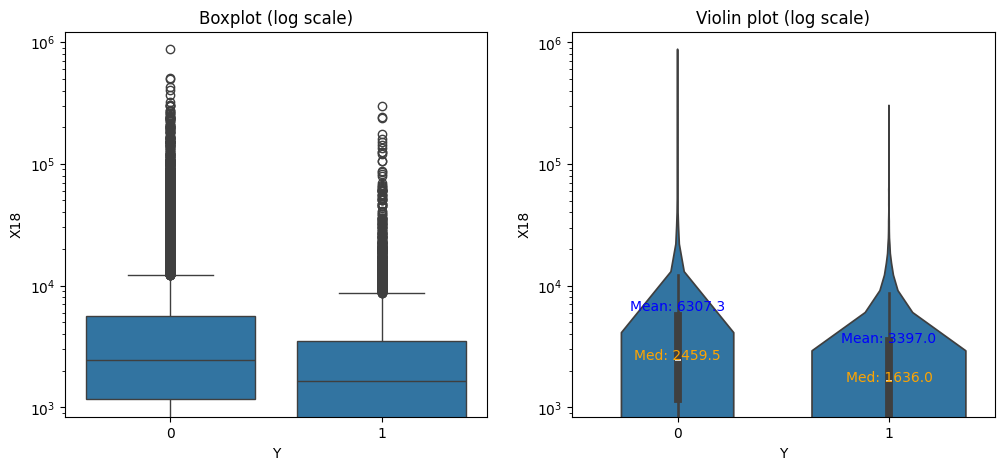

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot with log scale
sns.boxplot(x='Y', y='X18', data=df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Boxplot (log scale)')

# Violin shows the full distribution shape
sns.violinplot(x='Y', y='X18', data=df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Violin plot (log scale)')
stats = df.groupby('Y')['X18'].agg(['median', 'mean', lambda x: x.quantile(0.75)])

for i, category in enumerate(stats.index):
    mean = stats.loc[category, 'mean']
    median = stats.loc[category, 'median']
    axes[1].text(i, mean, f'Mean: {mean:.1f}', ha='center', color='blue')
    axes[1].text(i, median, f'Med: {median:.1f}', ha='center', color='orange')
plt.savefig("../imgs/x18_boxplot_violin.png")

In [3]:
import src.preprocessing
import importlib
importlib.reload(src.preprocessing)
import src.preprocessing as preprocessing
#df, features = load_data("../data/processed/44features.xls")
preprocessing.run_preprocessing(df)

(             X1        X5        X6        X7        X8        X9       X10  \
 2098  -0.270378  1.264658 -0.009120  0.105637  0.123024  0.188552  0.215916   
 5323  -1.116972 -0.149879  1.778485  1.765002  1.758634  0.188552  0.215916   
 13543  0.422289  1.264658 -0.009120  0.105637  0.123024  0.188552  0.215916   
 777    0.268363 -1.020363 -1.796724 -1.553729 -1.512586 -1.530834 -0.658346   
 13926  0.576215 -1.020363 -0.902922  1.765002 -0.694781 -0.671141  0.215916   
 ...         ...       ...       ...       ...       ...       ...       ...   
 9831   0.576215  2.026332 -0.902922 -0.724046 -0.694781  0.188552 -0.658346   
 11133 -0.886082  0.394174  0.884682 -1.553729 -1.512586 -0.671141 -0.658346   
 5060  -0.193415 -1.237984 -0.902922 -0.724046 -0.694781 -0.671141 -0.658346   
 14849 -0.270378 -0.911553 -0.009120  0.105637  0.123024  0.188552  0.215916   
 10222 -0.886082  0.611795 -0.009120  0.105637  0.123024  0.188552  0.215916   
 
             X11       X12       X13  